In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('parkinsons_disease_data.csv')

## Analysis of Dataset

In [2]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [3]:
display(df.shape)

(2105, 35)

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

None

In [5]:
# Check for null
display(df.isnull().sum().sum())

# Check for duplicates
display(df.duplicated().sum())

np.int64(0)

np.int64(0)

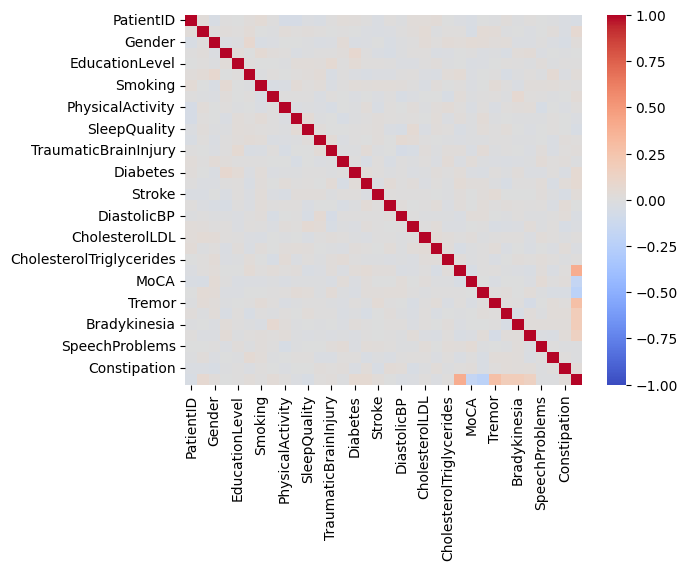

In [6]:
sns.heatmap(df.corr(numeric_only=True), cmap = "coolwarm", vmin=-1, vmax = 1)
plt.show()

In [7]:
# drop patient and doctor columns
df = df.drop(columns=['PatientID', 'DoctorInCharge'])

# dropping symptom columns (we want to predict based of demographic info not direct symptoms)
df = df.drop(columns=['UPDRS', 'MoCA', 'FunctionalAssessment', 'Tremor', 'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SpeechProblems', 'SleepDisorders', 'Constipation'])

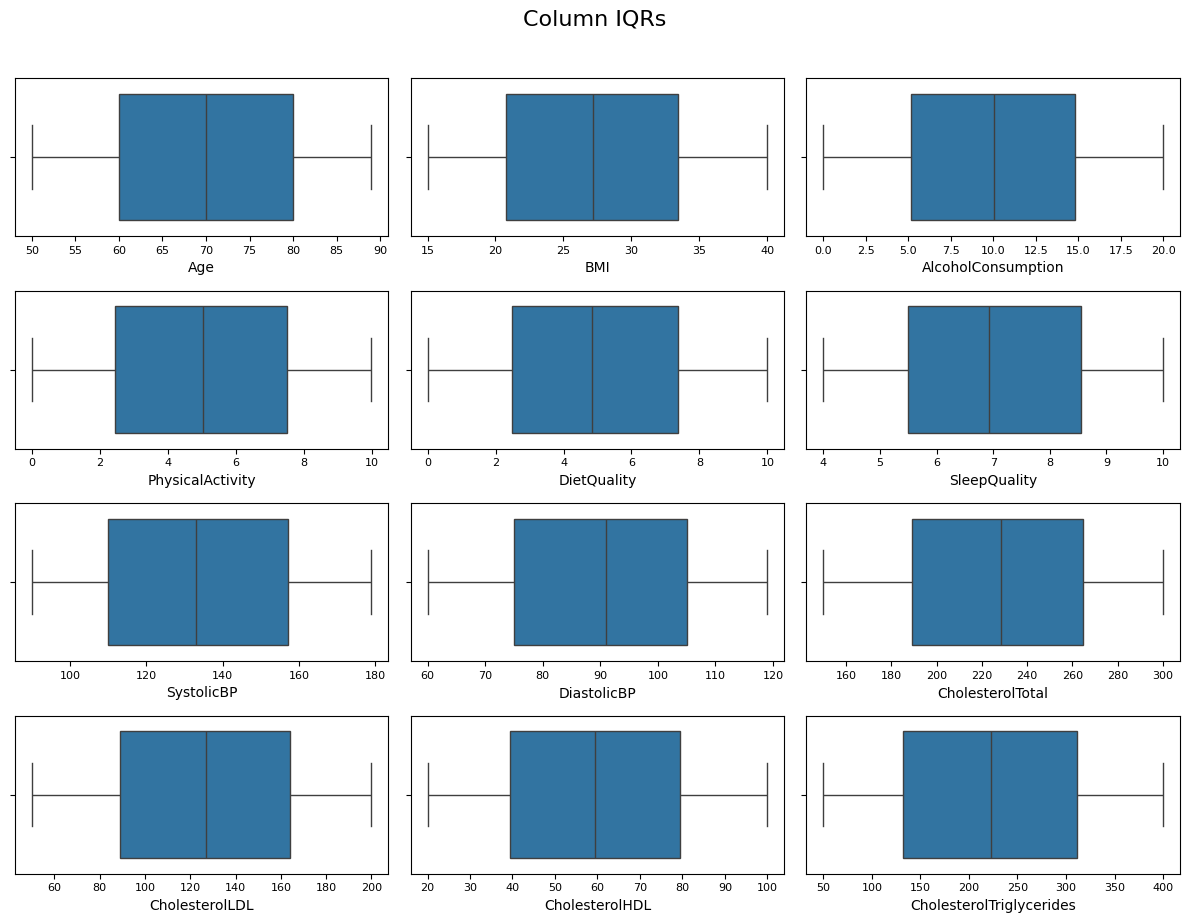

In [8]:
columns = df.drop(columns=[
    'Gender',
    'Ethnicity',
    'EducationLevel',
    'Smoking',
    'FamilyHistoryParkinsons',
    'TraumaticBrainInjury',
    'Hypertension',
    'Diabetes',
    'Depression',
    'Depression',
    'Stroke',
    'Diagnosis'
]).columns

fig, axes = plt.subplots(4, 3, figsize=(12, 9))
fig.suptitle("Column IQRs", fontsize=16, y=1.02)
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.boxplot(df[col], ax=axes[i], orient='h')
    axes[i].tick_params(labelsize=8)

# Hide unused subplots if df has fewer than 24 columns
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

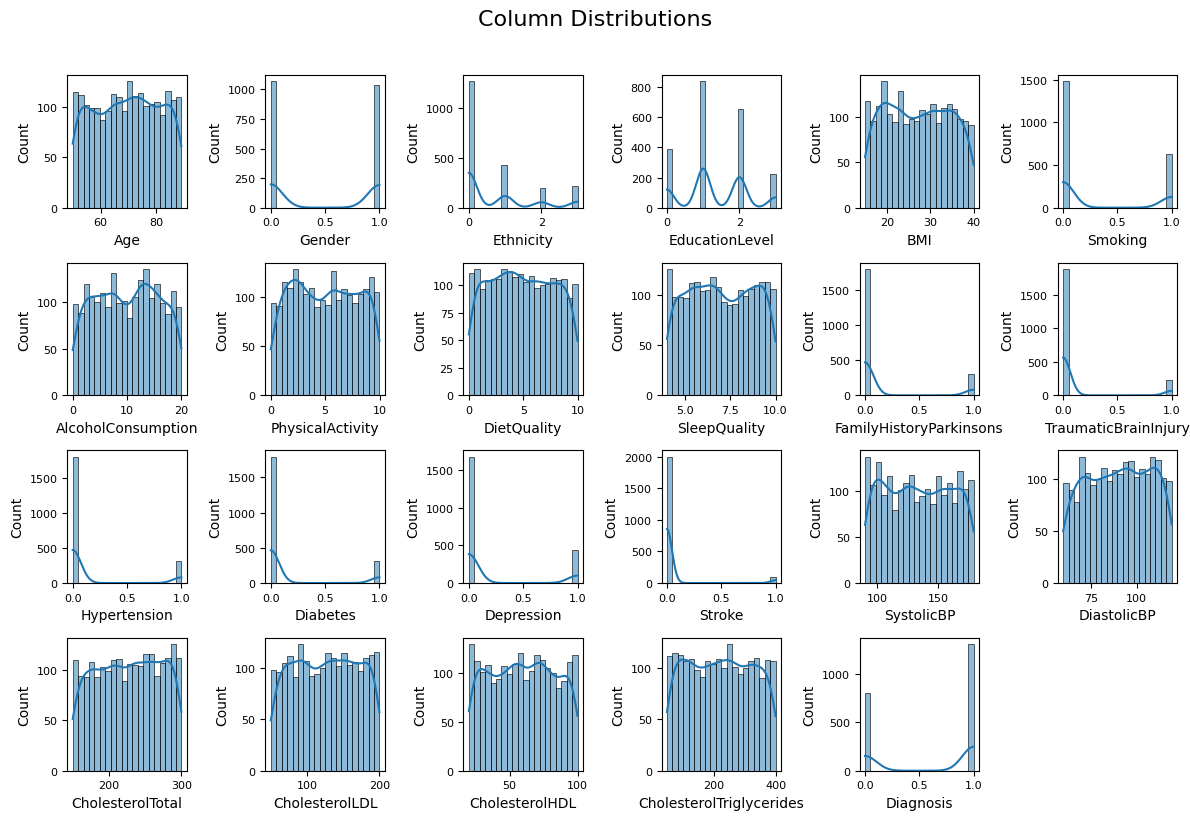

In [9]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
fig.suptitle("Column Distributions", fontsize=16, y=1.02)
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].tick_params(labelsize=8)

# Hide unused subplots if df has fewer than 24 columns
for j in range(len(df.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Distribution Assesment

Based on the above graphs, the data that is curently available is a nice spread including diverse samples. The main features that have uneven distributiuons are the binary ones. Things like smoking, family history, brain injury, etc, lean far more towards 0 than 1. However these binary features all seem to follow their resonable probabilities in a random population, therefore there isn't a need to sample or change much in their regard. The same goes for etnicity and education level, we will assume these accurately reflect the population to which the model will apply. With that said, the diagnosis column is the target of our model and should be even to prevent bias. This needs to be corrected, we will be using SMOTE to do so after the training and test data has been split.

Additionally we will be engineering a couple features: BMREstimate, GeneticMetabolicDispositionEstimate

## Preprocessing Dataset

In [10]:
temp = df.copy()
temp["Height_cm"] = temp["Gender"].apply(lambda x: 175 if x == 0 else 162) # estimates based on gender average
temp["Weight_kg"] = temp["BMI"] * (temp["Height_cm"] / 100)**2

# https://en.wikipedia.org/wiki/Harris–Benedict_equation#Calculating_the_Harris-Benedict_BMR
temp["BMREstimate"] = temp.apply(lambda row: 10*row["Weight_kg"] + 6.25*row["Height_cm"] - 5*row["Age"] - 166*row["Gender"] + 5, axis=1)

temp["LifestyleScore"] = (
    0.5*temp["DietQuality"] +
    0.3*temp["PhysicalActivity"] +
    0.2*temp["SleepQuality"]
)/5 - 1 # Weights based on intuition on importance for our purposes (normalized to be a number with range [-1, 1])

temp["GeneticMetabolicDispositionEstimate"] = temp["BMREstimate"] - 150 * temp["LifestyleScore"] # estimates a possible 150 kcal incluence either way based on lifestyle

# Adding newly engineered features
df["BMREstimate"] = temp["BMREstimate"]
df["GeneticMetabolicDispositionEstimate"] = temp["GeneticMetabolicDispositionEstimate"]

temp["LifeQualityScore"] = (
    0.2*temp["DietQuality"] +
    0.4*temp["PhysicalActivity"] +
    0.4*temp["SleepQuality"]
)/5 - 1 # Weights based on intuition on importance for our purposes (normalized to be a number with range [-1, 1])

temp["DepressionPredispositionEstimate"] = (temp["Depression"] * 5 - 2.5) + 2.5 * temp["LifeQualityScore"] + 5

import numpy as np

temp["NormalizedBP"] = (
    1 / (1 + np.exp(-((temp["SystolicBP"]/20 - 6) + (temp["DiastolicBP"]/10 - 8))/2))
)*2 - 1 # Weights based on intuition on importance for our purposes (normalized to be a number with range [-1, 1])
temp["DepressionPredispositionEstimate"] = (temp["Hypertension"] * 5 - 2.5) + 2.5 * temp["NormalizedBP"] + 5

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Diagnosis'])
Y = df.Diagnosis

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=1234)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1234)

# keeping old sets to compare sampled data and not sampled data
X_train_old, Y_train_old = X_train, Y_train

# Resample to balance Dataset
X_train, Y_train = smote.fit_resample(X_train, Y_train)
display(Y_train.value_counts().to_frame('count'))

def smote_and_not(func):
    models_1 = func(X_train, Y_train, X_test, Y_test)
    models_1["UsesSMOTE"] = 1
    models_1["label"] += ", smote"
    models_0 = func(X_train_old, Y_train_old, X_test, Y_test)
    models_0["UsesSMOTE"] = 0
    df = pd.concat([models_1, models_0], ignore_index=True)
    return df.sort_values(by=["label","UsesSMOTE"], ascending=True).reset_index(drop=True)

,count
Diagnosis,
1,1048
0,1048


## Training Models

### Regression Models

In [14]:
from models.regression import rg_run_models

rg_models = smote_and_not(rg_run_models)
rg_models # Show stats output as table

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix,ROC/AUC,UsesSMOTE
0,Elastic Net Regression,\tRandom State: 42,Regression,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,0
1,"Elastic Net Regression, smote",\tRandom State: 42,Regression,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,1
2,Lasso Regression,\tRandom State: 42,Regression,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,0
3,"Lasso Regression, smote",\tRandom State: 42,Regression,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,1
4,Linear Regression,\tDefault Settings,Regression,0.619952,0.619403,0.972656,0.756839,"[[12, 153], [7, 249]]",0.522692,0
5,"Linear Regression, smote",\tDefault Settings,Regression,0.529691,0.639423,0.519531,0.573276,"[[90, 75], [123, 133]]",0.532493,1
6,Logistic Regression,\tClass Weight: Balanced\n\tRandom State: 42,Regression,0.520190,0.622727,0.535156,0.575630,"[[82, 83], [119, 137]]",0.516063,0
7,Logistic Regression CV,\tClass Weight: Balanced\n\tSolver: Saga\n\tRa...,Regression,0.520190,0.623853,0.531250,0.573840,"[[83, 82], [120, 136]]",0.517140,0
8,"Logistic Regression CV, smote",\tClass Weight: Balanced\n\tSolver: Saga\n\tRa...,Regression,0.529691,0.639423,0.519531,0.573276,"[[90, 75], [123, 133]]",0.532493,1
9,"Logistic Regression, smote",\tClass Weight: Balanced\n\tRandom State: 42,Regression,0.534442,0.642857,0.527344,0.579399,"[[90, 75], [121, 135]]",0.536399,1


### RBF Kernel SVM

In [15]:
from models.svm import svm_run_models

svm_models = smote_and_not(svm_run_models)
svm_models # Show stats output as table

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix,UsesSMOTE
0,RBF Kernel,\tRegularization Param: 1\n\tKernel: RBF\n\tGa...,SVM,0.605701,0.614213,0.945312,0.744615,"[[13, 152], [14, 242]]",0
1,"RBF Kernel, smote",\tRegularization Param: 1\n\tKernel: RBF\n\tGa...,SVM,0.520190,0.603053,0.617188,0.610039,"[[61, 104], [98, 158]]",1


### Ensemble Models

In [16]:
from models.ensemble import ens_run_models

ens_models = smote_and_not(ens_run_models)
ens_models # Show stats output as table

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix,ROC/AUC,UsesSMOTE
0,AdaBoost Decision Tree,AdaBoost with 250 shallow Decision Trees as we...,ENS,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,0
1,"AdaBoost Decision Tree, smote",AdaBoost with 250 shallow Decision Trees as we...,ENS,0.610451,0.609524,1.000000,0.757396,"[[1, 164], [0, 256]]",0.503030,1
2,Bagging Decision Tree,Bagging Classifier with 100 Decision Tree base...,ENS,0.591449,0.603448,0.957031,0.740181,"[[4, 161], [11, 245]]",0.490637,0
3,"Bagging Decision Tree, smote",Bagging Classifier with 100 Decision Tree base...,ENS,0.610451,0.619171,0.933594,0.744548,"[[18, 147], [17, 239]]",0.521342,1
4,Random Forest,"Random Forest Classifier with 500 trees, min_s...",ENS,0.605701,0.607143,0.996094,0.754438,"[[0, 165], [1, 255]]",0.498047,0
5,"Random Forest, smote","Random Forest Classifier with 500 trees, min_s...",ENS,0.605701,0.611940,0.960938,0.747720,"[[9, 156], [10, 246]]",0.507741,1
6,Stacking RF+GB+KNN+DT,"Stacking Classifier combining RF, GB, KNN, DT ...",ENS,0.608076,0.608076,1.000000,0.756278,"[[0, 165], [0, 256]]",0.500000,0
7,"Stacking RF+GB+KNN+DT, smote","Stacking Classifier combining RF, GB, KNN, DT ...",ENS,0.600950,0.618919,0.894531,0.731629,"[[24, 141], [27, 229]]",0.519993,1


### Neural Network Model

In [17]:
from models.neural_net import nn_run_models

nn_models = smote_and_not(nn_run_models)
nn_models # Show stats output as table

,label,desc,model_type,accuracy,precision,recall,f1_score,confusion_matrix,ROC/AUC,UsesSMOTE
0,"elu, adam, binary_crossentropy","\tActivation function(s): elu, sigmoid\n\tLaye...",Neural Net,0.612827,0.623342,0.917969,0.756278,"[[[23, 142]], [21, 235]]",0.559695,0
1,"elu, adam, binary_crossentropy, smote","\tActivation function(s): elu, sigmoid\n\tLaye...",Neural Net,0.615202,0.616337,0.972656,0.756278,"[[[10, 155]], [7, 249]]",0.540885,1
2,"leaky_relu, adam, 1024y","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.596200,0.614362,0.902344,0.756278,"[[[20, 145]], [25, 231]]",0.533085,0
3,"leaky_relu, adam, 1024y, smote","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.572447,0.618750,0.773438,0.756278,"[[[43, 122]], [58, 198]]",0.533724,1
4,"leaky_relu, adam, binary_crossentropy","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.608076,0.620053,0.917969,0.756278,"[[[21, 144]], [21, 235]]",0.537204,0
5,"leaky_relu, adam, binary_crossentropy, 5 layers","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.608076,0.608076,1.000000,0.756278,"[[[0, 165]], [0, 256]]",0.584766,0
6,"leaky_relu, adam, binary_crossentropy, 5 layer...","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.608076,0.608076,1.000000,0.756278,"[[[0, 165]], [0, 256]]",0.551929,0
7,"leaky_relu, adam, binary_crossentropy, 5 layer...","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.603325,0.621918,0.886719,0.756278,"[[[27, 138]], [29, 227]]",0.549953,1
8,"leaky_relu, adam, binary_crossentropy, 5 layer...","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.605701,0.607143,0.996094,0.756278,"[[[0, 165]], [1, 255]]",0.527604,1
9,"leaky_relu, adam, binary_crossentropy, no_earl...","\tActivation function(s): leaky_relu, sigmoid\...",Neural Net,0.600950,0.621547,0.878906,0.756278,"[[[28, 137]], [31, 225]]",0.539500,0


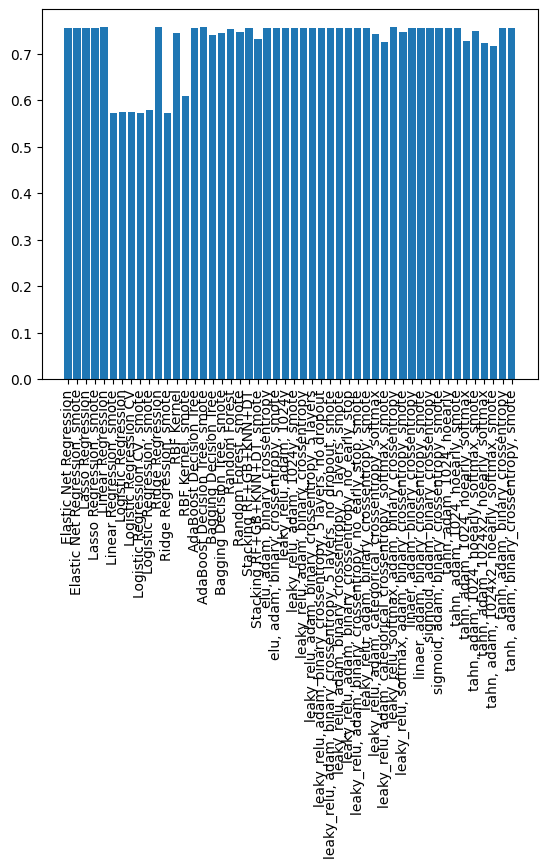

In [18]:
all_models = pd.concat([rg_models, svm_models, ens_models, nn_models], ignore_index=True)
plt.bar(all_models["label"], all_models["f1_score"])
plt.xticks(rotation='vertical')
plt.show()

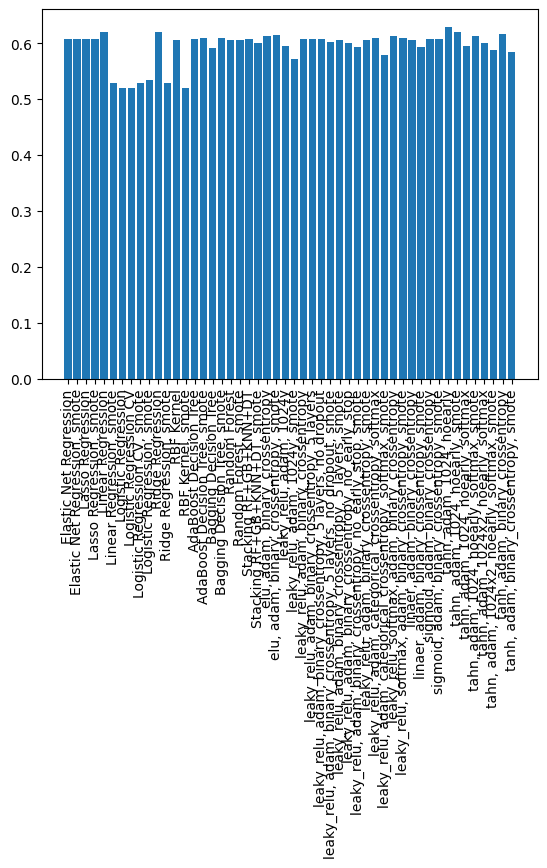

In [19]:
plt.bar(all_models["label"], all_models["accuracy"])
plt.xticks(rotation='vertical')
plt.show()